# 04 - Single-Dataset Latent Simulator

Configure one dataset, train the shared autoencoder and latent propagator, then identify which physical deformation variables the latent trajectory encodes and inspect autoregressive rollout quality.


In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.experiment import (
    initial_latent_analysis,
    prepare_source_spec,
    result_tables,
    rollout_curve_summary,
    save_result_tables,
    seed_everything,
    train_latent_experiment,
)
from lss.latent.simulation import pearson_r, r2_score
from lss.utils import resolve_device

plt.rcParams['figure.dpi'] = 110


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration


In [ ]:
seed = random.SystemRandom().randrange(1, 2**31)
seed_everything(seed)
print('run seed:', seed)

selected_dataset = 'reid'

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
        'train_count': 10,
        'val_count': 10,
    },
    'depablo': {
        'label': 'dePablo',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 30,
        'val_count': 25,
    },
    'depablo-10k-mix-temp': {
        'label': 'dePablo 10k mixed temperature',
        'path': 'data/depablo-10k-mix-temp.pt',
        'train_count': 80,
        'val_count': 50,
    },
}

cfg = {
    'dataset_name': selected_dataset,
    'split_seed': seed,
    # Balance temperature groups only when the selected dataset provides them.
    'split_stratify_temperature': selected_dataset == 'depablo-10k-mix-temp',
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 4,
    'frame_skip': 1,
    # Include the undeformed state because every rollout starts from frame 0.
    'train_frame_start_order': 0,
    'latent_dim': 2,
    'latent_tokens': 16,
    'hidden_size': 64,
    'edge_feature_dim': 8,
    # Cover the nonlinear transient and the rollout range being evaluated.
    'ae_max_train_frames_per_sim': 100,
    'dyn_max_train_transitions_per_sim': 100,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    # Preserve vertical motion, which together with horizontal compression controls p-ratio.
    'ae_coordinate_weights': [1.0, 2.0],
    'ae_max_epochs': 300,
    'ae_patience': 5,
    'ae_lr': 1e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 300,
    'dyn_patience': 5,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    'propagator_loss': 'delta',
    'propagator_objective': 'one_step',
    # Condition every latent update on reference geometry, topology and stiffness.
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,
    # The propagator learns z(t) -> z(t+k); rollout horizons remain physical frame counts.
    'propagator_step_stride': 1,
    'initial_velocity': 'zero',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [10, 20, 50, 100, 150, 300],
    'temperature_pratio_window': 'full',
    # Use evenly spaced frames for the interpretation sweep; first/final are retained.
    'descriptor_max_frames_per_sim': 60,
    'output_root': '../results/latent_space_simulator_single_dataset',
}

device = resolve_device(cfg['device'])
source_spec = prepare_source_spec(selected_dataset, dataset_specs, cfg, seed=seed)
run_dir = Path(cfg['output_root']) / selected_dataset / 'cv16_temperature_context'
run_dir.mkdir(parents=True, exist_ok=True)

print('dataset:', selected_dataset)
print('path:', source_spec['path'])
print('device:', device)
print('output:', run_dir)
display(pd.DataFrame([source_spec]))


run seed: 110703870
dataset: reid
path: /home/alexz/Documents/course_project/data/new_reid_combined.pt
device: cuda
output: ../results/latent_space_simulator_single_dataset/reid/cv16_temperature_context


,label,path,train_count,val_count,source_name,dataset_name,target_mode,ae_target_mode,node_feature_mode,latent_dim,...,ae_max_train_frames_per_sim,dyn_max_train_transitions_per_sim,ae_max_epochs,ae_patience,ae_lr,ae_weight_decay,dyn_max_epochs,dyn_patience,dyn_lr,dyn_weight_decay
0,Reid CV2 delta,/home/alexz/Documents/course_project/data/new_...,40,10,Reid,reid,delta,delta,delta,2,...,100,100,300,5,0.0001,0.00001,300,5,0.0001,0.00001


## Train Autoencoder And Latent Propagator



=== Reid CV2 delta ===
           source                                                           path  total  train  val  test
new_reid_combined /home/alexz/Documents/course_project/data/new_reid_combined.pt    102     40   10    52
autoencoder
ae 0001 train=0.486873 val=0.199862 stale=0
ae 0002 train=0.196577 val=0.165786 stale=0
ae 0004 train=0.17718 val=0.163386 stale=0
ae 0005 train=0.172456 val=0.159971 stale=0
ae 0006 train=0.171097 val=0.15746 stale=0
ae 0008 train=0.166217 val=0.154115 stale=0
ae 0010 train=0.163291 val=0.157565 stale=2
latent propagator: objective=one_step step_stride=1 train_rows=4000 val_rows=1000
propagator 0001 train=0.443226 val=0.21238 stale=0
propagator 0002 train=0.159511 val=0.176335 stale=0
propagator 0003 train=0.126924 val=0.157146 stale=0
rollout eval split=train: 6 horizons up to 300
rollout eval split=val: 6 horizons up to 300
rollout eval split=test: 6 horizons up to 300


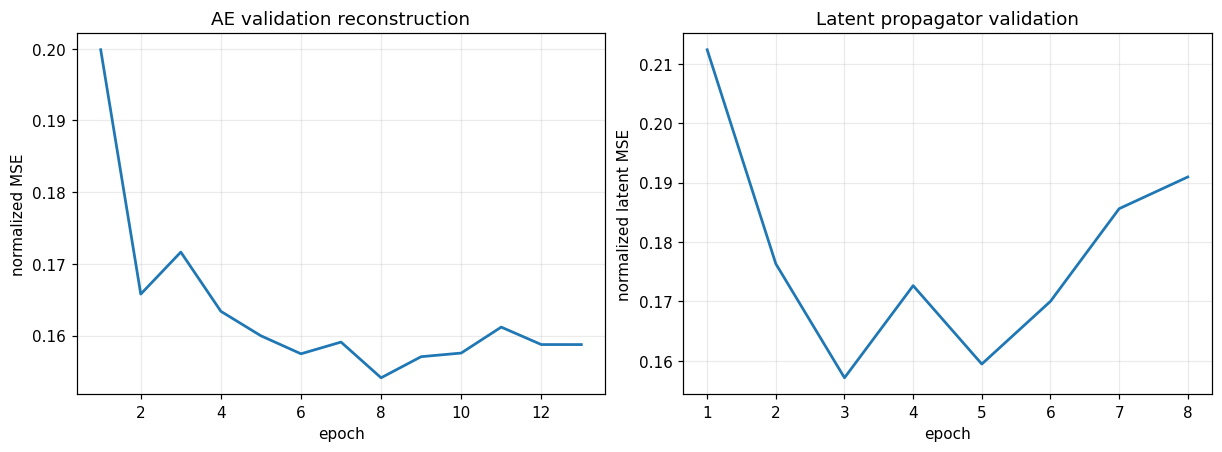

AE-only teacher-forced reconstruction (no propagator)


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,transverse_pos_mse,latent_dim,repeat_idx,model_seed,run_label
0,Reid CV2 delta,val,10,10,0.417487,0.962115,0.005171,0.000000,0.000000,0.000000,0.791569,0.060886,0.939114,0.000000,2,1,110705888,Reid CV2 delta
1,Reid CV2 delta,val,20,10,0.933531,0.974934,0.001337,0.000000,0.000001,0.000001,0.750210,0.050620,0.949380,0.000000,2,1,110705888,Reid CV2 delta
2,Reid CV2 delta,val,50,10,0.975078,0.989051,0.000784,0.000000,0.000008,0.000008,1.001563,0.041627,0.958373,0.000000,2,1,110705888,Reid CV2 delta
3,Reid CV2 delta,val,100,10,0.948768,0.988899,0.001846,0.000002,0.000031,0.000025,0.809305,0.067807,0.932193,0.000001,2,1,110705888,Reid CV2 delta
4,Reid CV2 delta,val,150,10,0.860632,0.976054,0.005237,0.000009,0.000072,0.000058,0.809401,0.122012,0.877988,0.000002,2,1,110705888,Reid CV2 delta
5,Reid CV2 delta,val,300,10,0.787337,0.904807,0.008377,0.000103,0.000296,0.000402,1.357121,0.347725,0.652275,0.000027,2,1,110705888,Reid CV2 delta
6,Reid CV2 delta,test,10,52,0.453149,0.926841,0.003825,0.000000,0.000000,0.000000,0.830968,0.046769,0.953231,0.000000,2,1,110705888,Reid CV2 delta
7,Reid CV2 delta,test,20,52,0.906500,0.961128,0.001509,0.000000,0.000001,0.000001,0.764011,0.045019,0.954981,0.000000,2,1,110705888,Reid CV2 delta
8,Reid CV2 delta,test,50,52,0.937527,0.979239,0.001782,0.000000,0.000008,0.000007,0.996340,0.054194,0.945806,0.000000,2,1,110705888,Reid CV2 delta
9,Reid CV2 delta,test,100,52,0.945312,0.972895,0.001919,0.000003,0.000031,0.000026,0.829860,0.082660,0.917340,0.000001,2,1,110705888,Reid CV2 delta


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,latent_dim,repeat_idx,model_seed,run_label
0,Reid CV2 delta,train,10,40,-0.17788,0.90425,0.00636,0.00000,0.00000,0.00000,0.93019,0.03834,0.96166,2,1,110705888,Reid CV2 delta
1,Reid CV2 delta,train,20,40,0.88485,0.94902,0.00153,0.00000,0.00000,0.00000,0.82125,0.03708,0.96292,2,1,110705888,Reid CV2 delta
2,Reid CV2 delta,train,50,40,0.89787,0.96209,0.00251,0.00000,0.00001,0.00001,0.98429,0.04701,0.95299,2,1,110705888,Reid CV2 delta
3,Reid CV2 delta,train,100,40,0.91510,0.96381,0.00267,0.00000,0.00003,0.00003,0.82666,0.06891,0.93109,2,1,110705888,Reid CV2 delta
4,Reid CV2 delta,train,150,40,0.87744,0.95426,0.00424,0.00001,0.00007,0.00006,0.91517,0.12127,0.87873,2,1,110705888,Reid CV2 delta
5,Reid CV2 delta,train,300,40,0.50505,0.92736,0.01917,0.00044,0.00029,0.00106,3.69990,1.52740,0.00000,2,1,110705888,Reid CV2 delta
6,Reid CV2 delta,val,10,10,0.50999,0.96115,0.00435,0.00000,0.00000,0.00000,0.80671,0.04107,0.95893,2,1,110705888,Reid CV2 delta
7,Reid CV2 delta,val,20,10,0.93405,0.96736,0.00133,0.00000,0.00000,0.00000,0.73396,0.04156,0.95844,2,1,110705888,Reid CV2 delta
8,Reid CV2 delta,val,50,10,0.91361,0.97469,0.00272,0.00000,0.00001,0.00001,0.92544,0.04059,0.95941,2,1,110705888,Reid CV2 delta
9,Reid CV2 delta,val,100,10,0.95586,0.98155,0.00159,0.00000,0.00003,0.00002,0.79634,0.06605,0.93395,2,1,110705888,Reid CV2 delta


In [3]:
seed_everything(source_spec['model_seed'])
result = train_latent_experiment(source_spec, cfg, device=device)
results = [result]

tables = result_tables(results)
save_result_tables(tables, run_dir)

ae_history_df = tables['ae_history']
dyn_history_df = tables['dyn_history']
rollout_rows_df = tables['rollout_rows']
rollout_stats_df = tables['rollout_stats']
ae_reconstruction_rows_df = tables['ae_reconstruction_rows']
ae_reconstruction_stats_df = tables['ae_reconstruction_stats']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(ae_history_df['epoch'], ae_history_df['val_mse_norm'], lw=1.8)
axes[0].set(title='AE validation reconstruction', xlabel='epoch', ylabel='normalized MSE')
axes[1].plot(dyn_history_df['epoch'], dyn_history_df['val_dz_mse_norm'], lw=1.8)
axes[1].set(title='Latent propagator validation', xlabel='epoch', ylabel='normalized latent MSE')
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

print('AE-only teacher-forced reconstruction (no propagator)')
display(ae_reconstruction_stats_df.round(6))

display(rollout_stats_df.round(5))


## Initial Latent P-Ratio Baseline

This is retained as a diagnostic, not as the primary interpretation. If the initial latent does not generalize to final p-ratio, the trajectory descriptor sweep below determines what the representation actually encodes.


No varying temperature metadata; skipping temperature-adjusted readouts.


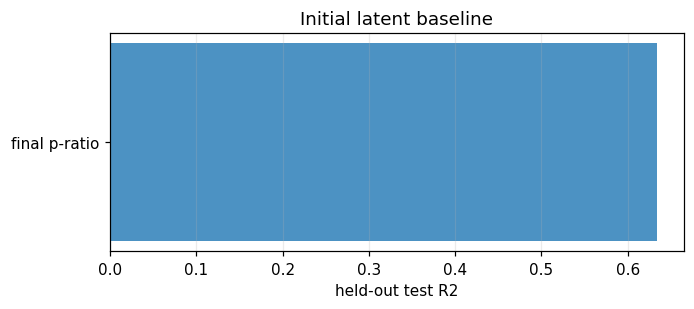

Linear combination used all coordinates: z0, z1
final p-ratio: test R2=0.633, r=0.821


In [4]:
latent_df, latent_corr_df = initial_latent_analysis(results, device=device)
latent_df.to_csv(run_dir / 'initial_latent_table.csv', index=False)
latent_corr_df.to_csv(run_dir / 'initial_latent_p_ratio_correlations.csv', index=False)

z_cols = sorted(
    [col for col in latent_df if col.startswith('z')],
    key=lambda col: int(col[1:]),
)
val_latent = latent_df[latent_df['split'].eq('val')].copy()
test_latent = latent_df[latent_df['split'].eq('test')].copy()

targets = {
    'final_p_ratio': 'final p-ratio',
}
temp_val_raw = val_latent['temperature'].to_numpy(float)
temp_test_raw = test_latent['temperature'].to_numpy(float)
has_temperature = (
    np.isfinite(temp_val_raw).all()
    and np.isfinite(temp_test_raw).all()
    and np.unique(temp_val_raw).size > 1
)
if has_temperature:
    # Ask whether z contains response information beyond temperature.
    temp_val = np.log1p(temp_val_raw)
    temp_test = np.log1p(temp_test_raw)
    temp_design_val = np.column_stack([np.ones(len(temp_val)), temp_val])
    temp_coef = np.linalg.lstsq(
        temp_design_val, val_latent['final_p_ratio'].to_numpy(float), rcond=None,
    )[0]
    val_latent['temperature_adjusted_p_ratio'] = (
        val_latent['final_p_ratio'] - temp_design_val @ temp_coef
    )
    test_latent['temperature_adjusted_p_ratio'] = (
        test_latent['final_p_ratio']
        - np.column_stack([np.ones(len(temp_test)), temp_test]) @ temp_coef
    )
    targets.update({
        'temperature': 'temperature',
        'temperature_adjusted_p_ratio': 'temp-adjusted p-ratio',
    })
else:
    print('No varying temperature metadata; skipping temperature-adjusted readouts.')
X_val = val_latent[z_cols].to_numpy(float)
X_test = test_latent[z_cols].to_numpy(float)
x_mean = X_val.mean(axis=0)
x_std = X_val.std(axis=0) + 1e-12
design_val = np.column_stack([np.ones(len(X_val)), (X_val - x_mean) / x_std])
design_test = np.column_stack([np.ones(len(X_test)), (X_test - x_mean) / x_std])

readout_rows = []
weight_rows = []
test_predictions = {}
for target, label in targets.items():
    y_val = val_latent[target].to_numpy(float)
    y_test = test_latent[target].to_numpy(float)
    coef = np.linalg.lstsq(design_val, y_val, rcond=None)[0]
    pred = design_test @ coef
    test_predictions[target] = pred
    readout_rows.append({
        'target': label,
        'test_r2': r2_score(y_test, pred),
        'test_pearson_r': pearson_r(y_test, pred),
    })
    weight_rows.append({
        'target': label,
        'intercept': float(coef[0] - np.sum(coef[1:] * x_mean / x_std)),
        **{f'{col}_weight': float(weight) for col, weight in zip(z_cols, coef[1:] / x_std)},
    })

latent_readout_df = pd.DataFrame(readout_rows)
latent_readout_weights_df = pd.DataFrame(weight_rows)
latent_readout_df.to_csv(run_dir / 'initial_latent_linear_readout_scores.csv', index=False)
latent_readout_weights_df.to_csv(run_dir / 'initial_latent_linear_readout_weights.csv', index=False)

score_plot = latent_readout_df.sort_values('test_r2')
colors = ['tab:red' if value < 0 else 'tab:blue' for value in score_plot['test_r2']]
fig, ax = plt.subplots(figsize=(6.2, 2.7), constrained_layout=True)
ax.barh(score_plot['target'], score_plot['test_r2'], color=colors, alpha=0.8)
ax.axvline(0, color='0.25', lw=1)
ax.set(title='Initial latent baseline', xlabel='held-out test R2')
ax.grid(axis='x', alpha=0.25)
plt.show()

print('Linear combination used all coordinates:', ', '.join(z_cols))
for row in latent_readout_df.itertuples(index=False):
    print(f'{row.target}: test R2={row.test_r2:.3f}, r={row.test_pearson_r:.3f}')


## What The Latent Trajectory Encodes

Sweep horizontal and vertical node motion, normalized box-size changes, average edge-length change, motion not explained by uniform box deformation, and an elastic-energy proxy. Every linear combination is fitted on validation networks and scored on held-out test networks.


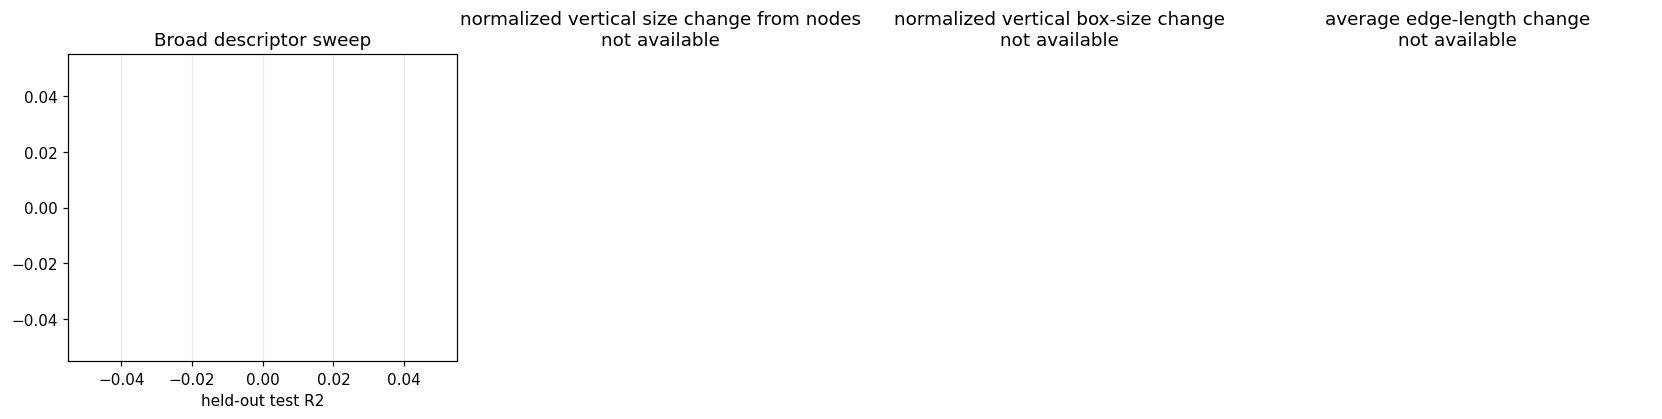

Strongest held-out latent-state readouts


In [5]:
descriptor_frame_df, descriptor_score_df, descriptor_prediction_df, descriptor_weight_df = (
    framewise_latent_descriptor_sweep(
        result,
        device=device,
        frame_stride=1,
        max_frames_per_sim=cfg.get('descriptor_max_frames_per_sim', 60),
    )
)
descriptor_score_df.to_csv(run_dir / 'framewise_latent_descriptor_scores.csv', index=False)
descriptor_weight_df.to_csv(run_dir / 'framewise_latent_descriptor_weights.csv', index=False)

target_labels = {
    'affine_yy': 'normalized vertical size change from nodes',
    'box_strain_y': 'normalized vertical box-size change',
    'box_area_strain': 'normalized box-area change',
    'affine_xx': 'normalized horizontal size change from nodes',
    'rms_dx': 'horizontal node-motion magnitude',
    'edge_stretch_mean': 'average edge-length change',
    'edge_rel_stretch_mean': 'average normalized edge-length change',
    'rms_disp': 'total node-motion magnitude',
    'nonaffine_rms': 'non-uniform node-motion magnitude',
    'spring_energy_proxy': 'spring-energy proxy',
    'frame_progress': 'trajectory progress',
}
state_scores = (
    descriptor_score_df[descriptor_score_df['feature_set'].eq('latent state')]
    .sort_values('test_r2', ascending=False)
)
plot_scores = state_scores.head(8).sort_values('test_r2')

fig, axes = plt.subplots(1, 4, figsize=(15, 3.7), constrained_layout=True)
axes[0].barh(
    [target_labels.get(target, target) for target in plot_scores['target']],
    plot_scores['test_r2'], color='tab:blue', alpha=0.8,
)
axes[0].set(title='Broad descriptor sweep', xlabel='held-out test R2')
axes[0].grid(axis='x', alpha=0.25)

detail_targets = ['affine_yy', 'box_strain_y', 'edge_stretch_mean']
descriptor_temperatures = descriptor_prediction_df['temperature'].to_numpy(float)
color_by_temperature = np.isfinite(descriptor_temperatures).any()
temperature_points = None
for ax, target in zip(axes[1:], detail_targets):
    sub = descriptor_prediction_df[
        descriptor_prediction_df['feature_set'].eq('latent state')
        & descriptor_prediction_df['target'].eq(target)
    ]
    score_rows = state_scores.loc[state_scores['target'].eq(target), 'test_r2']
    if sub.empty or score_rows.empty:
        ax.set(title=f'{target_labels[target]}\nnot available')
        ax.axis('off')
        continue
    scatter_kwargs = {'c': sub['temperature'], 'cmap': 'viridis'} if color_by_temperature else {'color': 'tab:blue'}
    points = ax.scatter(
        sub['observed'], sub['predicted'], s=8, alpha=0.22,
        rasterized=True, **scatter_kwargs,
    )
    if color_by_temperature:
        temperature_points = points
    lo, hi = np.nanmin(np.r_[sub['observed'], sub['predicted']]), np.nanmax(np.r_[sub['observed'], sub['predicted']])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    score = score_rows.iloc[0]
    ax.set(
        title=f'{target_labels[target]}\nR2={score:.3f}',
        xlabel='observed', ylabel='latent readout',
    )
    ax.grid(alpha=0.25)
if temperature_points is not None:
    fig.colorbar(temperature_points, ax=axes[1:], pad=0.01, label='temperature')
plt.show()

print('Strongest held-out latent-state readouts')
for row in state_scores.head(10).itertuples(index=False):
    label = target_labels.get(row.target, row.target)
    print(
        f'{label}: test R2={row.test_r2:.3f}, '
        f'mean within-network r={row.mean_within_network_r:.3f}'
    )


### Interpretation

The latent trajectory primarily records **how the network changes shape**. It strongly predicts normalized vertical size change (`dy / initial height`), normalized horizontal size change (`dx / initial width`), box-area change, node-motion magnitude, and average edge-length change. These correlations remain strong within individual test trajectories, so they are not explained only by temperature or network identity.

It is much weaker at describing irregular local motion: node motion left after removing the best uniform shape change is only partially represented, while variation in edge-length changes and the spring-energy proxy are poorly predicted across networks. Therefore the latent should be interpreted as encoding the smooth overall shape-change path rather than detailed local elastic behavior.


## P-Ratio Along The Trajectory

P-ratio is calculated from normalized vertical and horizontal size changes: `-(dy / initial height) / (dx / initial width)`. We therefore compare direct latent-to-p-ratio fits with a physical two-step calculation: use the latent to predict normalized `dx` and `dy`, then calculate p-ratio from those predicted trajectories. Cumulative and rolling definitions test how much temporal averaging is required before the ratio becomes stable.


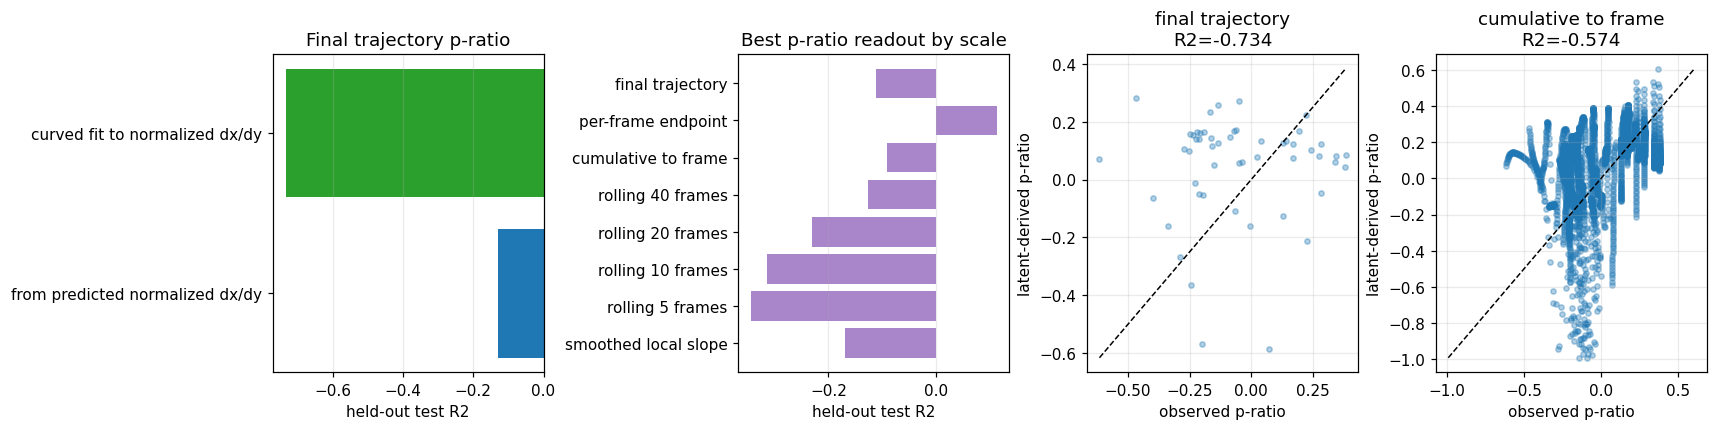

Best held-out p-ratio readouts
final trajectory: R2=-0.111 using latent change via predicted normalized dx/dy
per-frame endpoint: R2=0.114 using latent state via predicted normalized dx/dy
cumulative to frame: R2=-0.090 using latent change via predicted normalized dx/dy
rolling 40 frames: R2=-0.127 using latent change via predicted normalized dx/dy
rolling 20 frames: R2=-0.230 using latent change via predicted normalized dx/dy
rolling 10 frames: R2=-0.315 using latent change via predicted normalized dx/dy
rolling 5 frames: R2=-0.345 using latent change via predicted normalized dx/dy
smoothed local slope: R2=-0.169 using latent change via predicted normalized dx/dy


In [6]:
p_ratio_labels = {
    'side_final_trajectory_p_ratio': 'final trajectory',
    'side_endpoint_p_ratio': 'per-frame endpoint',
    'side_cumulative_p_ratio': 'cumulative to frame',
    'side_rolling_40_p_ratio': 'rolling 40 frames',
    'side_rolling_20_p_ratio': 'rolling 20 frames',
    'side_rolling_10_p_ratio': 'rolling 10 frames',
    'side_rolling_5_p_ratio': 'rolling 5 frames',
    'side_local_p_ratio': 'smoothed local slope',
}
p_ratio_scores = descriptor_score_df[
    descriptor_score_df['target'].isin(p_ratio_labels)
].copy()
best_by_target = (
    p_ratio_scores.sort_values('test_r2', ascending=False)
    .drop_duplicates('target')
)

final_methods = [
    'latent state',
    'quadratic latent state',
    'latent state via side strains',
    'quadratic latent state via side strains',
]
final_comparison = p_ratio_scores[
    p_ratio_scores['target'].eq('side_final_trajectory_p_ratio')
    & p_ratio_scores['feature_set'].isin(final_methods)
].set_index('feature_set').reindex(final_methods).reset_index()

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.8), constrained_layout=True)
method_labels = [
    'direct linear', 'direct curved fit',
    'from predicted normalized dx/dy',
    'curved fit to normalized dx/dy',
]
axes[0].barh(method_labels, final_comparison['test_r2'], color=['0.55', '0.4', 'tab:blue', 'tab:green'])
axes[0].set(title='Final trajectory p-ratio', xlabel='held-out test R2')
axes[0].grid(axis='x', alpha=0.25)

timescale_order = [
    'side_local_p_ratio', 'side_rolling_5_p_ratio', 'side_rolling_10_p_ratio',
    'side_rolling_20_p_ratio', 'side_rolling_40_p_ratio',
    'side_cumulative_p_ratio', 'side_endpoint_p_ratio',
    'side_final_trajectory_p_ratio',
]
timescale_scores = best_by_target.set_index('target').reindex(timescale_order).dropna(subset=['test_r2'])
axes[1].barh(
    [p_ratio_labels[target] for target in timescale_scores.index],
    timescale_scores['test_r2'], color='tab:purple', alpha=0.8,
)
axes[1].set(title='Best p-ratio readout by scale', xlabel='held-out test R2')
axes[1].grid(axis='x', alpha=0.25)

scatter_specs = [
    ('side_final_trajectory_p_ratio', 'quadratic latent state via side strains'),
    ('side_cumulative_p_ratio', 'quadratic latent state via side strains'),
]
p_ratio_temperatures = descriptor_prediction_df['temperature'].to_numpy(float)
color_by_temperature = np.isfinite(p_ratio_temperatures).any()
temperature_points = None
for ax, (target, feature_set) in zip(axes[2:], scatter_specs):
    sub = descriptor_prediction_df[
        descriptor_prediction_df['target'].eq(target)
        & descriptor_prediction_df['feature_set'].eq(feature_set)
    ].copy()
    if target == 'side_final_trajectory_p_ratio':
        sub = sub.drop_duplicates('sim_idx')
    score_rows = p_ratio_scores.loc[
        p_ratio_scores['target'].eq(target)
        & p_ratio_scores['feature_set'].eq(feature_set),
        'test_r2',
    ]
    if sub.empty or score_rows.empty:
        ax.set(title=f'{p_ratio_labels[target]}\nnot available')
        ax.axis('off')
        continue
    scatter_kwargs = {'c': sub['temperature'], 'cmap': 'viridis'} if color_by_temperature else {'color': 'tab:blue'}
    points = ax.scatter(
        sub['observed'], sub['predicted'], s=12, alpha=0.35,
        rasterized=True, **scatter_kwargs,
    )
    if color_by_temperature:
        temperature_points = points
    lo, hi = np.nanmin(np.r_[sub['observed'], sub['predicted']]), np.nanmax(np.r_[sub['observed'], sub['predicted']])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    score = score_rows.iloc[0]
    ax.set(
        title=f'{p_ratio_labels[target]}\nR2={score:.3f}',
        xlabel='observed p-ratio', ylabel='latent-derived p-ratio',
    )
    ax.grid(alpha=0.25)
if temperature_points is not None:
    fig.colorbar(temperature_points, ax=axes[2:], pad=0.01, label='temperature')
plt.show()

print('Best held-out p-ratio readouts')
for target in timescale_order[::-1]:
    row = best_by_target[best_by_target['target'].eq(target)]
    if row.empty:
        continue
    row = row.iloc[0]
    method = row.feature_set.replace('side strains', 'predicted normalized dx/dy')
    method = method.replace('quadratic', 'curved')
    print(f'{p_ratio_labels[target]}: R2={row.test_r2:.3f} using {method}')


## Autoregressive Rollout


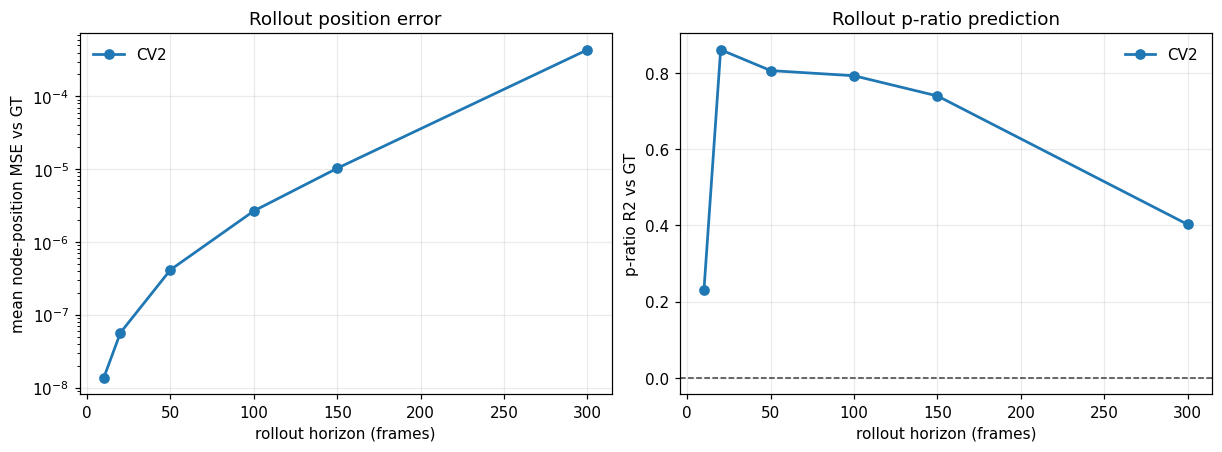

,latent_dim,split,rollout_steps,final_pos_mse,p_ratio_mse,used,p_ratio_r2,p_ratio_pearson
0,2,test,10,0.000000,0.005383,52,0.230372,0.910957
1,2,test,20,0.000000,0.002246,52,0.860868,0.935717
2,2,test,50,0.000000,0.005530,52,0.806143,0.928481
3,2,test,100,0.000003,0.007276,52,0.792589,0.915656
4,2,test,150,0.000010,0.009869,52,0.739566,0.903139
5,2,test,300,0.000437,0.024926,52,0.402405,0.849186


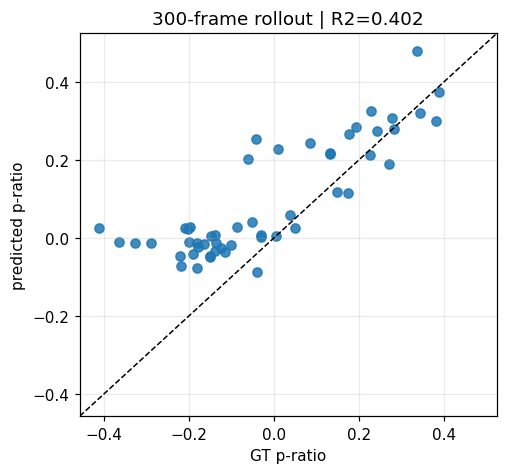

In [7]:
rollout_by_repeat_df, rollout_curve_df = rollout_curve_summary(rollout_rows_df)
rollout_by_repeat_df.to_csv(run_dir / 'rollout_error_vs_steps_by_repeat.csv', index=False)
rollout_curve_df.to_csv(run_dir / 'rollout_error_vs_steps.csv', index=False)

test_curve = rollout_curve_df[rollout_curve_df['split'].eq('test')].sort_values('rollout_steps')
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for latent_dim, group in test_curve.groupby('latent_dim'):
    label = f'CV{int(latent_dim)}'
    axes[0].plot(group['rollout_steps'], group['final_pos_mse'], marker='o', lw=1.8, label=label)
    axes[1].plot(group['rollout_steps'], group['p_ratio_r2'], marker='o', lw=1.8, label=label)
axes[0].set(
    title='Rollout position error',
    xlabel='rollout horizon (frames)',
    ylabel='mean node-position MSE vs GT',
    yscale='log',
)
axes[1].set(
    title='Rollout p-ratio prediction',
    xlabel='rollout horizon (frames)',
    ylabel='p-ratio R2 vs GT',
)
axes[1].axhline(0, color='0.25', lw=1, ls='--')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()

display(test_curve.round(6))

if not rollout_rows_df.empty:
    chosen_step = int(rollout_rows_df.loc[rollout_rows_df['split'].eq('test'), 'rollout_steps'].max())
    scatter_df = rollout_rows_df[
        rollout_rows_df['split'].eq('test')
        & rollout_rows_df['rollout_steps'].eq(chosen_step)
    ]
    x = scatter_df['true_p_ratio'].to_numpy(float)
    y = scatter_df['pred_p_ratio'].to_numpy(float)
    lo, hi = np.nanmin(np.r_[x, y]), np.nanmax(np.r_[x, y])
    pad = 0.05 * max(hi - lo, 1e-6)

    fig, ax = plt.subplots(figsize=(4.5, 4.2), constrained_layout=True)
    temperatures = scatter_df['temperature'].to_numpy(float)
    if np.isfinite(temperatures).sum() and len(np.unique(temperatures[np.isfinite(temperatures)])) > 1:
        points = ax.scatter(x, y, c=temperatures, cmap='viridis', s=36, alpha=0.85)
        fig.colorbar(points, ax=ax, pad=0.02, label='temperature')
    else:
        ax.scatter(x, y, s=36, alpha=0.85)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1)
    ax.set(
        xlim=(lo - pad, hi + pad), ylim=(lo - pad, hi + pad),
        title=f'{chosen_step}-frame rollout | R2={r2_score(x, y):.3f}',
        xlabel='GT p-ratio', ylabel='predicted p-ratio',
    )
    ax.grid(alpha=0.25)
    plt.show()
